# 02 — Acurácia factual

A acurácia factual é a **dimensão principal** do estudo. Sem ela, qualquer ganho em concisão, latência ou custo perde sentido.

**Como ela é construída.** Cada resposta foi avaliada por dois juízes-LLM independentes (ChatGPT e Claude), cada um devolvendo `1` (resposta correta segundo o edital), `0,5` (parcialmente correta) ou `0` (incorreta/insuficiente). Onde os juízes convergiram, o valor agregado é direto. Onde divergiram, um juiz humano desempatou. A coluna final é `avaliacao_final ∈ {0, 0,5, 1}` e a média por modelo é o que chamamos de **acurácia factual**.

Este notebook responde quatro perguntas:

1. **Quem acerta mais?** — ranking direto, com IC bootstrap.
2. **As diferenças entre modelos próximos são significativas?** — pareadas Chat vs API, comparações agrupadas por provedor.
3. **Onde os juízes discordam mais?** — concordância modelo a modelo, e o que isso diz sobre a qualidade da resposta.
4. **A acurácia factual depende da categoria da pergunta?** — apresentado em segundo plano, porque o efeito por modelo é muito maior que o efeito por categoria.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, PARES_CHAT_API,
                   MARKER_API, MARKER_CHAT, PROVEDOR, MODELO_DISPLAY,
                   titulo_acima, bootstrap_ic, plot_barras_pareadas,
                   legenda_provedor_origem)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)

## 1. Ranking de acurácia factual

Cada barra é a média de `avaliacao_final` sobre 150 respostas, com IC bootstrap 95%. O hachurado nos chats web reforça a leitura: **bolinha vs quadrado** é a convenção que vai aparecer em todos os scatters; aqui, em barras, traduzimos isso em **sólido vs hachurado**.


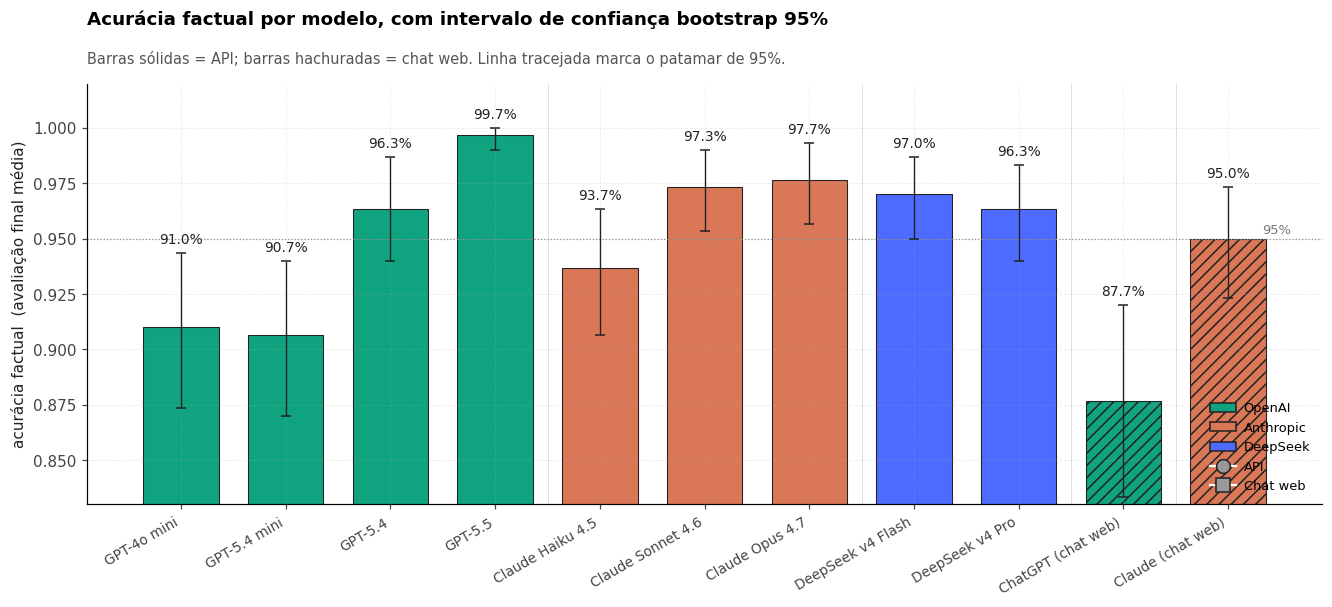

In [2]:
# Calcula IC bootstrap por modelo
ic = []
for nome in ORDEM_MODELOS:
    serie = df.loc[df['modelo_display'] == nome, 'avaliacao_final']
    lo, hi = bootstrap_ic(serie, n_boot=2000, ci=0.95)
    ic.append({'modelo': nome, 'media': serie.mean(), 'lo': lo, 'hi': hi})
ic_df = pd.DataFrame(ic).set_index('modelo')

fig, ax = plt.subplots(figsize=(12, 5.4), layout='constrained')

# Plota as barras manualmente (sem rótulo no topo, vamos por nós mesmos
# acima da barra de erro).
xs = np.arange(len(ORDEM_MODELOS))
cores = mestre['cor'].values
canais = mestre['origem'].values

bars = ax.bar(xs, ic_df['media'].values, color=cores, edgecolor='#222',
              linewidth=0.7, width=0.72)
for b, c in zip(bars, canais):
    if c == 'Chat web':
        b.set_hatch('///')

# Barras de erro
err = np.vstack([(ic_df['media'] - ic_df['lo']).values,
                 (ic_df['hi'] - ic_df['media']).values])
ax.errorbar(xs, ic_df['media'].values, yerr=err,
            fmt='none', ecolor='#222', elinewidth=0.9, capsize=3, zorder=4)

# Rótulos % acima da barra de erro superior
for x, m, hi in zip(xs, ORDEM_MODELOS, ic_df['hi'].values):
    ax.text(x, hi + 0.003, f'{ic_df.loc[m, "media"]*100:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#222')

# Separadores entre provedores
last = None
for i, p in enumerate(mestre['provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_MODELOS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('acurácia factual  (avaliação final média)')
ax.set_ylim(0.83, 1.02)
ax.axhline(0.95, ls=':', color='#888', lw=0.8, zorder=1)
ax.text(len(ORDEM_MODELOS) - 0.4, 0.951, '95%', fontsize=8.5, color='#777',
        va='bottom', ha='right')

legenda_provedor_origem(ax, loc='lower right')

titulo_acima(ax,
    'Acurácia factual por modelo, com intervalo de confiança bootstrap 95%',
    'Barras sólidas = API; barras hachuradas = chat web. Linha tracejada marca o patamar de 95%.')

plt.show()

**O que aparece no ranking.**

- **GPT-5.5 lidera com folga**: 99,7% — apenas duas respostas foram apontadas como incorretas em 150. O IC nem chega a tocar os 98%.
- **Acima de 95%**: Claude Opus 4.7, Claude Sonnet 4.6, DeepSeek v4 Flash, GPT-5.4 e DeepSeek v4 Pro. Os ICs se sobrepõem entre si — não há separação estatística entre esses cinco.
- **O chat web de Claude está nesse patamar (95,0%)**, enquanto o **chat web do ChatGPT é o mais fraco** da amostra (87,7%) — abaixo até de Haiku 4.5 e GPT-5.4 mini. O canal navegador, sem a ferramenta de busca instrumentada, paga preço em acurácia factual.

A próxima seção isola essa diferença canal-a-canal — o ponto mais importante do TCC.


## 2. Pareadas: Chat web vs API do mesmo provedor

Aqui colocamos cada chat web contra o modelo mais alto da sua família via API. É a comparação que responde à pergunta de fundo do estudo: **vale a pena instrumentar o modelo via API com uma ferramenta de busca, ou o usuário tira o mesmo proveito usando o produto comercial pelo navegador?**


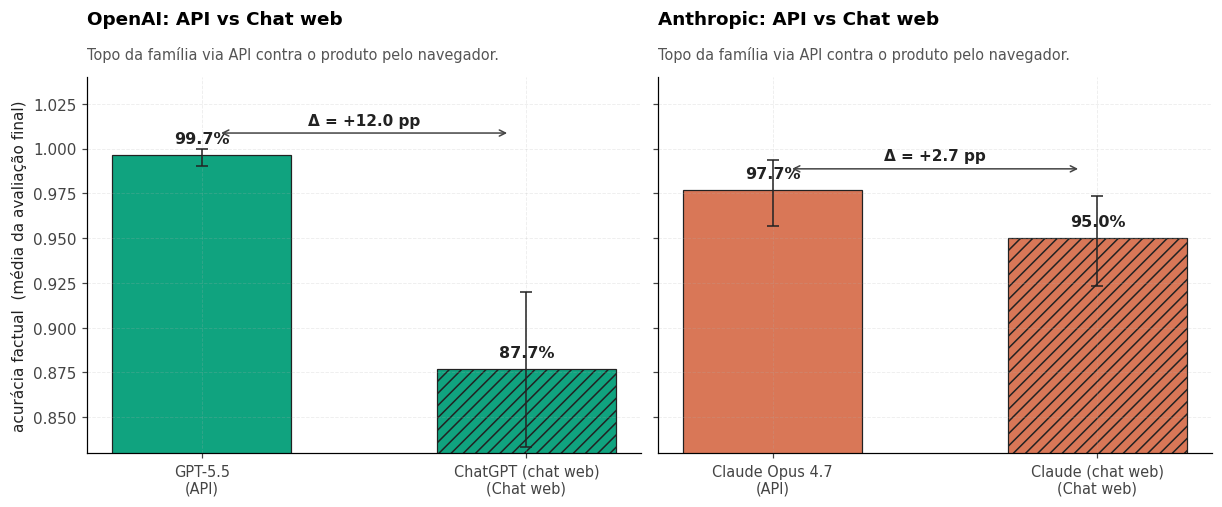

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True, layout='constrained')

# Largura das barras e posição
W = 0.55

for ax, (chat, api) in zip(axes, PARES_CHAT_API):
    sub = mestre.loc[[chat, api]]
    provedor = sub['provedor'].iloc[0]
    cor_base = CORES_PROVEDOR[provedor]

    # ordem visual: API esq, Chat dir
    rotulos = [api, chat]
    valores = [sub.loc[api, 'precisao'], sub.loc[chat, 'precisao']]
    canais  = ['API', 'Chat web']
    xs = np.arange(2)

    bars = ax.bar(xs, valores, color=cor_base, edgecolor='#222',
                  linewidth=0.8, width=W)
    bars[1].set_hatch('///')

    # IC bootstrap em cada uma
    for i, m in enumerate(rotulos):
        s = df.loc[df['modelo_display'] == m, 'avaliacao_final']
        lo, hi = bootstrap_ic(s, n_boot=2000)
        ax.errorbar(xs[i], s.mean(),
                    yerr=[[s.mean()-lo],[hi-s.mean()]],
                    fmt='none', ecolor='#222', elinewidth=1.0, capsize=4, zorder=4)

    # Rótulos
    for i, (v, m, c) in enumerate(zip(valores, rotulos, canais)):
        ax.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', va='bottom',
                fontsize=10.5, fontweight='bold', color='#222')

    # Diferença, anotada DENTRO do plot (entre as duas barras)
    delta = valores[0] - valores[1]
    sinal = '+' if delta > 0 else ''
    y_seta = max(valores) + 0.012
    ax.annotate('', xy=(0.05, y_seta), xytext=(0.95, y_seta),
                arrowprops=dict(arrowstyle='<->', color='#444', lw=1))
    ax.text(0.5, y_seta + 0.003, f'Δ = {sinal}{delta*100:.1f} pp',
            ha='center', va='bottom',
            fontsize=10, color='#222', fontweight='bold')

    ax.set_xticks(xs)
    ax.set_xticklabels([f'{rotulos[0]}\n(API)', f'{rotulos[1]}\n(Chat web)'],
                       fontsize=9.5)
    ax.set_ylim(0.83, 1.04)

    titulo_acima(ax, f'{provedor}: API vs Chat web',
                 f'Topo da família via API contra o produto pelo navegador.')

axes[0].set_ylabel('acurácia factual  (média da avaliação final)')

plt.show()

**A leitura.**

- **OpenAI**: GPT-5.5 (API + ferramenta) chega a 99,7%; ChatGPT (chat web) faz 87,7%. **Diferença de 12 pontos percentuais.** Os ICs nem se aproximam — a separação é categórica.
- **Anthropic**: Claude Opus 4.7 faz 97,7% via API; o chat web de Claude faz 95,0%. **Diferença menor, 2,7 pp**, mas o IC do chat ainda fica abaixo. O chat web de Claude é, dos dois, o mais competitivo contra sua versão API.

A intuição que sustenta o estudo se confirma: **a ferramenta de consulta ao edital tem efeito não desprezível na acurácia factual**, e o efeito é maior no caso da OpenAI. Os notebooks 04 (latência) e 05 (custo) vão mostrar que esse ganho não sai de graça.


## 3. Agrupadas por provedor: o panorama em "small multiples"

Outra forma de olhar a tabela: três paineizinhos lado a lado, um por provedor. Esse formato deixa claro como cada família escala internamente — do modelo "mini" ao "topo de linha".


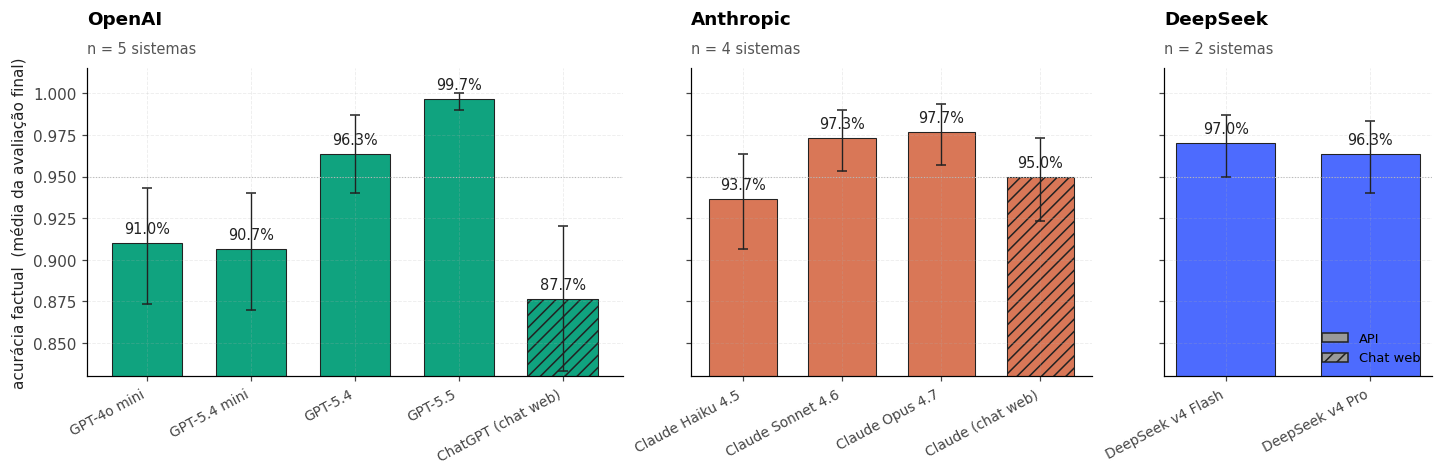

In [4]:
# Painéis por provedor
provedores_ord = ['OpenAI', 'Anthropic', 'DeepSeek']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True,
                         layout='constrained',
                         gridspec_kw={'width_ratios': [4, 3, 2]})

for ax, prov in zip(axes, provedores_ord):
    sub = mestre[mestre['provedor'] == prov]
    cor = CORES_PROVEDOR[prov]

    rotulos = sub.index.tolist()
    valores = sub['precisao'].values
    canais  = sub['origem'].values
    xs = np.arange(len(rotulos))

    bars = ax.bar(xs, valores, color=cor, edgecolor='#222',
                  linewidth=0.7, width=0.68)
    for b, c in zip(bars, canais):
        if c == 'Chat web':
            b.set_hatch('///')

    # ICs
    for i, m in enumerate(rotulos):
        s = df.loc[df['modelo_display'] == m, 'avaliacao_final']
        lo, hi = bootstrap_ic(s, n_boot=2000)
        ax.errorbar(xs[i], s.mean(),
                    yerr=[[s.mean()-lo],[hi-s.mean()]],
                    fmt='none', ecolor='#222', elinewidth=0.9, capsize=3, zorder=4)
        ax.text(i, valores[i] + 0.004, f'{valores[i]*100:.1f}%',
                ha='center', va='bottom', fontsize=9.5, color='#222')

    ax.set_xticks(xs)
    ax.set_xticklabels(rotulos, rotation=28, ha='right', fontsize=9)
    ax.set_ylim(0.83, 1.015)
    ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
    titulo_acima(ax, prov, f'n = {len(sub)} sistemas')

axes[0].set_ylabel('acurácia factual  (média da avaliação final)')

# Legenda canal só uma vez, no canto da figura
from matplotlib.patches import Patch
leg = [
    Patch(facecolor='#999', edgecolor='#222', label='API'),
    Patch(facecolor='#999', edgecolor='#222', hatch='///', label='Chat web'),
]
axes[-1].legend(handles=leg, loc='lower right', fontsize=8.5)

plt.show()

**O que dá pra ler família por família.**

- **OpenAI**: escala monotônica nos modelos via API (GPT-4o mini < GPT-5.4 mini < GPT-5.4 < GPT-5.5). O chat web fica abaixo de todos eles. O ganho de instrumentar a API é o maior do estudo.
- **Anthropic**: acurácia factual alta e plana entre os três modelos via API (todos entre 94% e 98%). O chat web fica ligeiramente abaixo dos Opus/Sonnet, mas competitivo. O contraste API vs Chat é o menor dos três provedores.
- **DeepSeek**: dois modelos próximos (Flash 97%, Pro 96,3%) — diferença dentro do ruído de bootstrap. Sem chat web comercial nesta família.


## 4. Onde os juízes discordam

A `avaliacao_final` esconde uma camada anterior: a opinião individual de cada juiz. A próxima visão mostra a **taxa de concordância** entre ChatGPT-juiz e Claude-juiz, modelo a modelo. Uma concordância baixa não significa que o modelo está errado — pode significar apenas que a resposta cai numa zona ambígua que os dois juízes interpretam de forma distinta (resposta "parcialmente coberta", por exemplo).


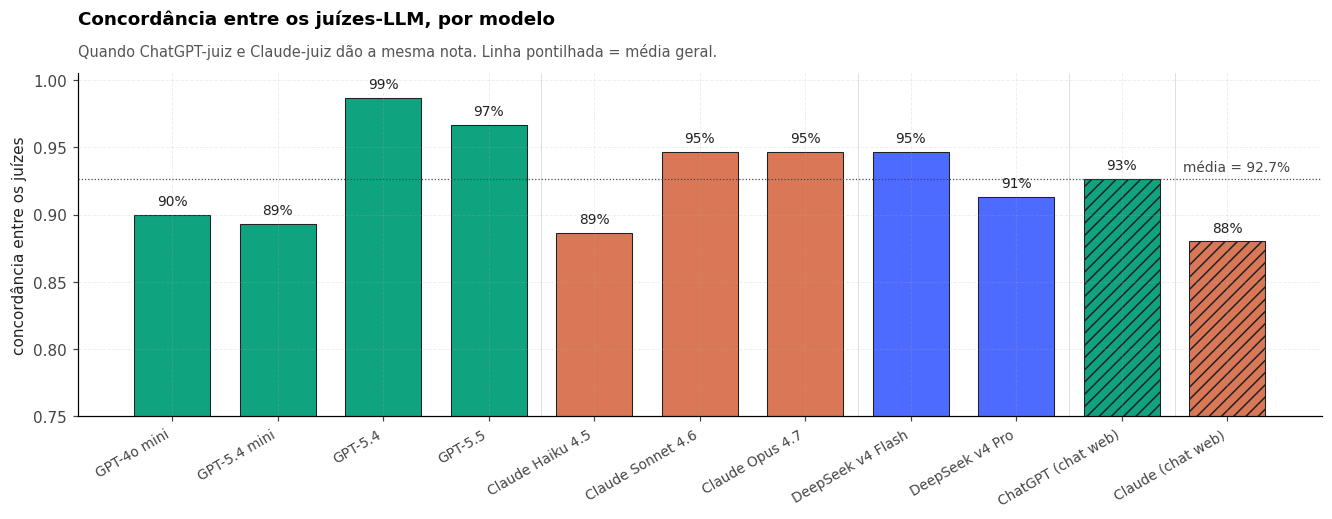

Concordância média geral: 92.7%
Voto humano necessário em: 121 / 1650 casos (7.3%)


In [5]:
concord = (df.groupby('modelo_display')
              .apply(lambda x: (x['avaliacao_gpt'] == x['avaliacao_opus']).mean())
              .reindex(ORDEM_MODELOS))

fig, ax = plt.subplots(figsize=(12, 4.6), layout='constrained')

cores_b = [mestre.loc[m, 'cor'] for m in ORDEM_MODELOS]
xs = np.arange(len(ORDEM_MODELOS))
bars = ax.bar(xs, concord.values, color=cores_b, edgecolor='#222',
              linewidth=0.7, width=0.72)
for b, c in zip(bars, [mestre.loc[m, 'origem'] for m in ORDEM_MODELOS]):
    if c == 'Chat web':
        b.set_hatch('///')

# linha em 90% como referência
ax.axhline(concord.mean(), ls=':', color='#444', lw=0.8)
ax.text(len(xs)-0.4, concord.mean() + 0.003,
        f'média = {concord.mean()*100:.1f}%',
        ha='right', va='bottom', fontsize=9, color='#444')

for x, v in zip(xs, concord.values):
    ax.text(x, v + 0.005, f'{v*100:.0f}%', ha='center', va='bottom',
            fontsize=9, color='#222')

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_MODELOS, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.75, 1.005)
ax.set_ylabel('concordância entre os juízes')

# Separadores entre provedores
last = None
for i, p in enumerate([mestre.loc[m, 'provedor'] for m in ORDEM_MODELOS]):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

titulo_acima(ax,
    'Concordância entre os juízes-LLM, por modelo',
    'Quando ChatGPT-juiz e Claude-juiz dão a mesma nota. Linha pontilhada = média geral.')

plt.show()

print(f'Concordância média geral: {(df["avaliacao_gpt"] == df["avaliacao_opus"]).mean()*100:.1f}%')
print(f'Voto humano necessário em: {(~df["convergencia"]).sum()} / {len(df)} casos '
      f'({(~df["convergencia"]).mean()*100:.1f}%)')

**O padrão das divergências.**

- **Concordância alta em quem acerta muito.** GPT-5.5, Claude Opus 4.7 e Claude Sonnet 4.6 ficam acima de 95% de concordância — quando a resposta é claramente correta, os dois juízes vêem isso da mesma forma.
- **Concordância cai onde a acurácia factual cai.** ChatGPT (chat web) e GPT-4o mini têm as duas piores taxas de concordância. As respostas são mais ambíguas, e os juízes brigam mais sobre elas.
- **Anthropic vs OpenAI nos modelos médios.** A diferença é pequena, mas os modelos Anthropic tendem a ter concordância ligeiramente maior — talvez por gerarem respostas mais explícitas (e mais longas), que deixam o critério de avaliação mais claro para ambos os juízes.

Onde os juízes divergiram (cerca de **7,3%** do total, ou 121 casos), um avaliador humano desempatou. A `avaliacao_final` usada em todo o estudo já incorpora esse desempate.


## 5. Acurácia factual por categoria de pergunta (segundo plano)

Conforme combinado, este recorte é secundário — o efeito por modelo é dezenas de vezes maior que o efeito por categoria. Mas vale guardar a foto para conferir que **não há uma categoria onde um modelo ruim vire bom ou vice-versa**.


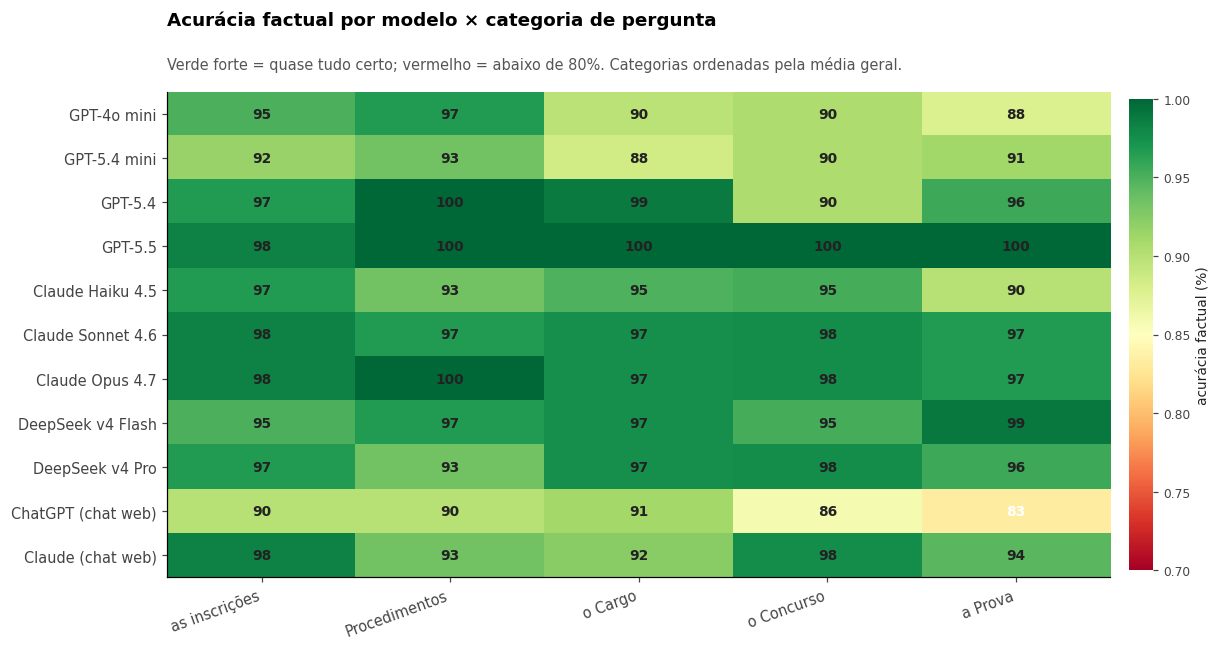

In [6]:
# Heatmap modelo × categoria
heat = (df.groupby(['modelo_display', 'categoria'])['avaliacao_final']
          .mean().unstack('categoria').loc[ORDEM_MODELOS])

# Ordenar colunas por acurácia factual geral decrescente
ordem_cat = heat.mean().sort_values(ascending=False).index.tolist()
heat = heat[ordem_cat]

fig, ax = plt.subplots(figsize=(11, 5.8), layout='constrained')
im = ax.imshow(heat.values, cmap='RdYlGn', vmin=0.7, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([c.replace('Dados sobre ', '') for c in heat.columns],
                   rotation=20, ha='right', fontsize=9.5)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=9.5)

# Anotar células
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        cor = '#222' if v > 0.85 else '#fff'
        ax.text(j, i, f'{v*100:.0f}', ha='center', va='center',
                fontsize=9, color=cor, fontweight='bold')

cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('acurácia factual (%)', fontsize=9)
cb.ax.tick_params(labelsize=8)
cb.outline.set_visible(False)

ax.grid(False)
titulo_acima(ax,
    'Acurácia factual por modelo × categoria de pergunta',
    'Verde forte = quase tudo certo; vermelho = abaixo de 80%. Categorias ordenadas pela média geral.')

plt.show()

**Como ler.** O gradiente é dominado pela linha (modelo), não pela coluna (categoria). GPT-5.5 é a única linha quase toda em verde-escuro; o chat web de ChatGPT é a única com vermelhos espalhados. Nenhuma categoria de pergunta cria um padrão diagonal — ou seja, ninguém é especialista numa categoria específica.

**Ponto fraco mais consistente.** "Dados sobre as inscrições" e "Dados sobre Procedimentos" são as categorias com mais variação entre modelos. Já "Dados sobre o Cargo" é a mais fácil — todos os sistemas, inclusive os mais fracos, acertam acima de 88% nela.

---

A acurácia factual isolada já estabelece a hierarquia geral do estudo. O próximo notebook traz a **concisão** — quem responde direto ao ponto sem perder a substância. É lá que algumas dessas precisões altas mostram custo escondido em forma de texto longo.
